# Brain age prediction on MS data (smoothed asymmetry, m6 scans)

## Imports and paths

In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import nibabel as nib
import matplotlib.pyplot as plt
import pyreadstat

# fastMONAI / fastai / MONAI
from fastMONAI.vision_all import *
from fastai.learner import Learner
from fastai.losses import L1LossFlat
from fastai.metrics import mae
from monai.networks.nets import Regressor

/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Root directory for thesis project
ms_root = Path("/hus/home/aaasen/Master_thesis")

image_dir = ms_root / "VBM_project_MS_m6" / "T1_scans"

# Metadata file (participants / clinical info)
ms_participants_path = ms_root / "Metadata_OFAMS" / "follow_up_info.csv"


# Path til edss.sav
edss_path = Path("/hus/home/aaasen/Master_thesis/Metadata_OFAMS/edss.sav")

## Load MS metadata

In [3]:
df_part = pd.read_csv(ms_participants_path)
df_part.head()

,Unnamed: 0,Patnr,Sex_OFAMS10,Age_BL_OFAMS,Age_OFAMS10,EDSS_score_10
0,1,101,1.0,35.0,47.0,2
1,2,103,0.0,24.0,36.0,1
2,3,104,1.0,48.0,59.0,"1,5"
3,4,201,0.0,50.0,62.0,2
4,5,202,1.0,31.0,43.0,0


In [4]:
df_part.dtypes

Unnamed: 0         int64
Patnr              int64
Sex_OFAMS10      float64
Age_BL_OFAMS     float64
Age_OFAMS10      float64
EDSS_score_10     object
dtype: object

In [5]:
df_part['Age_BL_OFAMS']= df_part['Age_BL_OFAMS'] + 0.5 # changes from the baseline age to the m6-age (0.5 years older)

df_part = df_part.rename(columns={
    'Patnr': 'participant_id',
    'Sex_OFAMS10': 'sex',
    'Age_BL_OFAMS': 'age_m6'})


df_part = df_part.drop(columns=["Unnamed: 0"])
df_part = df_part.drop(columns=["Age_OFAMS10"])
df_part = df_part.drop(columns=["EDSS_score_10"])
df_part["sex"] = df_part["sex"].map({0: "M", 1: "F"}) # 1=female, 0=male

In [6]:
df_part.head()

,participant_id,sex,age_m6
0,101,F,35.5
1,103,M,24.5
2,104,F,48.5
3,201,M,50.5
4,202,F,31.5


In [7]:
df_part.dtypes

participant_id      int64
sex                object
age_m6            float64
dtype: object

## Load EDSS data

In [8]:
edss_df, meta = pyreadstat.read_sav(edss_path)

edss_df.head()

,Patnr,BL_EDSSscore,M6_EDSSscore,M12_EDSSscore,M18_EDSSscore,M24_EDSSscore
0,101.0,1.5,2.0,2.0,2.0,2.0
1,103.0,2.5,1.0,1.0,1.0,0.0
2,104.0,1.5,1.5,2.0,1.5,1.5
3,201.0,1.5,2.5,2.5,2.5,2.5
4,202.0,1.0,1.0,1.0,0.0,0.0


In [9]:
edss_m6 = edss_df[["Patnr", "M6_EDSSscore"]].copy()

# Gi kolonnen samme navn som i df_part
edss_m6 = edss_m6.rename(columns={
    "Patnr": "participant_id",
    "M6_EDSSscore": "EDSS_m6"
})

edss_m6.head()

,participant_id,EDSS_m6
0,101.0,2.0
1,103.0,1.0
2,104.0,1.5
3,201.0,2.5
4,202.0,1.0


In [10]:
edss_m6["participant_id"] = edss_m6["participant_id"].astype(int)

In [11]:
edss_m6.dtypes

participant_id      int64
EDSS_m6           float64
dtype: object

In [12]:
df_part = df_part.merge(
    edss_m6,
    on="participant_id",
    how="left"
)

print("Number with m6-EDSS:", df_part["EDSS_m6"].notna().sum())
df_part.head()

Number with m6-EDSS: 88


,participant_id,sex,age_m6,EDSS_m6
0,101,F,35.5,2.0
1,103,M,24.5,1.0
2,104,F,48.5,1.5
3,201,M,50.5,2.5
4,202,F,31.5,1.0


## Remove subjects with missing age

In [13]:
# Removing rows with NaN values in age_m6 
df_part = df_part.dropna(subset=["age_m6"])
df_part.head()

,participant_id,sex,age_m6,EDSS_m6
0,101,F,35.5,2.0
1,103,M,24.5,1.0
2,104,F,48.5,1.5
3,201,M,50.5,2.5
4,202,F,31.5,1.0


In [14]:
min_age_new = df_part["age_m6"].min()
max_age_new = df_part["age_m6"].max()

print("Ages at month 24:")
print(f"Min age: {min_age_new}")
print(f"Max age: {max_age_new}")

Ages at month 24:
Min age: 19.5
Max age: 58.5


## Build dataframe linking images to subject metadata

In [15]:
from pathlib import Path
import pandas as pd

rows = []

# Finn alle m6 step4_warped-filer rekursivt
# Bytt pattern hvis asymmetrifilene dine har annet navn.
image_paths = sorted(image_dir.rglob("m6/mri/step4_warped/sAI_mwrp1sub-*_ses-m6_ce-GADOLINIUM_*_affine.nii*"))

print("Found image files:", len(image_paths))
if len(image_paths) > 0:
    print("Example:", image_paths[0])

for p in image_paths:
    fname = p.name

    # 1) Prøv å hente ID fra filnavn: "...sub-101..."
    participant_id = None
    if "sub-" in fname:
        try:
            participant_id = fname.split("sub-")[1].split("_")[0]
        except IndexError:
            participant_id = None

    # 2) Fallback: hent ID fra mappestruktur: .../T1_scans/101/m6/...
    if participant_id is None:
        # p.parts inneholder alle mappenavn i stien
        # Finn indeksen til "T1_scans" og ta neste element (= subject folder, f.eks. "101")
        parts = p.parts
        if "T1_scans" in parts:
            i = parts.index("T1_scans")
            if i + 1 < len(parts):
                participant_id = parts[i + 1]

    if participant_id is None:
        print("Could not parse subject ID from:", p)
        continue

    # Match metadata
    match = df_part[df_part["participant_id"].astype(str) == str(participant_id)]

    if len(match) == 1:
        rows.append({
            "image_path": str(p),
            "participant_id": str(participant_id),
            "sex": match["sex"].values[0],
            "age_m6": match["age_m6"].values[0],
            "EDSS_m6": match["EDSS_m6"].values[0],
        })
    else:
        print("Metadata not found (or not unique) for subject:", participant_id, "matches:", len(match))

df_ms = pd.DataFrame(rows)

print("Number of MS scans:", len(df_ms))
df_ms.head()

Found image files: 85
Example: /hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/101/m6/mri/step4_warped/sAI_mwrp1sub-101_ses-m6_ce-GADOLINIUM_T1w_affine.nii
Number of MS scans: 85


,image_path,participant_id,sex,age_m6,EDSS_m6
0,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/101/m6/mri/step4_warped/sAI_mwrp1sub-101_ses-m6_ce-GADOLINIUM_T1w_affine.nii,101,F,35.5,2.0
1,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/103/m6/mri/step4_warped/sAI_mwrp1sub-103_ses-m6_ce-GADOLINIUM_T1w_affine.nii,103,M,24.5,1.0
2,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/104/m6/mri/step4_warped/sAI_mwrp1sub-104_ses-m6_ce-GADOLINIUM_T1w_affine.nii,104,F,48.5,1.5
3,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/1101/m6/mri/step4_warped/sAI_mwrp1sub-1101_ses-m6_ce-GADOLINIUM_T1w_affine.nii,1101,F,46.5,1.5
4,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/1102/m6/mri/step4_warped/sAI_mwrp1sub-1102_ses-m6_ce-GADOLINIUM_T1w_affine.nii,1102,F,39.5,2.0


## Build DataBlock

In [16]:
import pickle
from pathlib import Path

# Path til lagrede preprocessing-parametere
preproc_path = Path("/hus/home/aaasen/Master_thesis/smoothed_model/smoothed_preproc_params.pkl")

with open(preproc_path, "rb") as f:
    preproc = pickle.load(f)

resample = preproc["resample"]
reorder  = preproc["reorder"]

print("Preprocessing parameters loaded successfully.")
print("Resample:", resample)
print("Reorder:", reorder)

Preprocessing parameters loaded successfully.
Resample: [1.5, 1.5, 1.5]
Reorder: False


In [17]:
# Identical to baseline_train
in_shape = [1, 128, 160, 128]

item_tfms = [ZNormalization(), PadOrCrop(in_shape[1:])]

In [18]:
dblock = MedDataBlock(
    blocks=(ImageBlock(cls=MedImage), RegressionBlock),
    splitter=None,  # no splitting for inference
    get_x=ColReader("image_path"),
    get_y=ColReader("age_m6"),  # used only for analysis
    item_tfms=item_tfms,
    apply_reorder=reorder,
    target_spacing=resample
)

dls = dblock.dataloaders(df_ms, bs=4)

## Load model

In [19]:
model = Regressor(
    in_shape=in_shape,
    out_shape=1,
    channels=(64, 128, 256, 256, 256),
    strides=(2, 2, 2, 2),
    kernel_size=3,
    num_res_units=2
)

In [20]:
learn = Learner(
    dls,
    model,
    loss_func=L1LossFlat(), 
    metrics=[mae],
)

from pathlib import Path

learn.path = Path("/hus/home/aaasen/Master_thesis/smoothed_model")
learn.model_dir = ""   # siden filen ligger direkte i mappen

# Load trained weights
learn.load("smoothed_baseline_best")

Saved file doesn't contain an optimizer state.


In [21]:
learn.model.eval()

Regressor(
  (net): Sequential(
    (layer_0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (layer_1): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
         

## Brain age predictions and brain age gap

In [22]:
test_dl = dls.test_dl(df_ms, with_labels=True)

In [23]:
preds, targs = learn.get_preds(dl=test_dl) # test = the whole dataset when splitter=None

y_pred = preds.squeeze().cpu().numpy()
y_true = targs.squeeze().cpu().numpy()

df_ms["predicted_age"] = y_pred
df_ms["brain_age_gap"] = y_pred - df_ms["age_m6"]

df_ms.head()

,image_path,participant_id,sex,age_m6,EDSS_m6,predicted_age,brain_age_gap
0,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/101/m6/mri/step4_warped/sAI_mwrp1sub-101_ses-m6_ce-GADOLINIUM_T1w_affine.nii,101,F,35.5,2.0,45.781872,10.281872
1,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/103/m6/mri/step4_warped/sAI_mwrp1sub-103_ses-m6_ce-GADOLINIUM_T1w_affine.nii,103,M,24.5,1.0,29.445108,4.945108
2,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/104/m6/mri/step4_warped/sAI_mwrp1sub-104_ses-m6_ce-GADOLINIUM_T1w_affine.nii,104,F,48.5,1.5,27.582979,-20.917021
3,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/1101/m6/mri/step4_warped/sAI_mwrp1sub-1101_ses-m6_ce-GADOLINIUM_T1w_affine.nii,1101,F,46.5,1.5,42.505901,-3.994099
4,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/1102/m6/mri/step4_warped/sAI_mwrp1sub-1102_ses-m6_ce-GADOLINIUM_T1w_affine.nii,1102,F,39.5,2.0,52.435074,12.935074


## Bias correction

In [24]:
# Load bias correction parameters estimated on train set
a, b = np.load("smoothed_bias_correction_params.npy")
y_pred_bc = (y_pred - b) / a

df_ms["predicted_age_bc"] = (df_ms["predicted_age"] - b) / a
df_ms["brain_age_gap_bc"] = df_ms["predicted_age_bc"] - df_ms["age_m6"]

In [25]:
df_ms.head()

,image_path,participant_id,sex,age_m6,EDSS_m6,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc
0,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/101/m6/mri/step4_warped/sAI_mwrp1sub-101_ses-m6_ce-GADOLINIUM_T1w_affine.nii,101,F,35.5,2.0,45.781872,10.281872,46.289124,10.789124
1,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/103/m6/mri/step4_warped/sAI_mwrp1sub-103_ses-m6_ce-GADOLINIUM_T1w_affine.nii,103,M,24.5,1.0,29.445108,4.945108,30.196196,5.696196
2,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/104/m6/mri/step4_warped/sAI_mwrp1sub-104_ses-m6_ce-GADOLINIUM_T1w_affine.nii,104,F,48.5,1.5,27.582979,-20.917021,28.361860,-20.138140
3,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/1101/m6/mri/step4_warped/sAI_mwrp1sub-1101_ses-m6_ce-GADOLINIUM_T1w_affine.nii,1101,F,46.5,1.5,42.505901,-3.994099,43.062050,-3.437950
4,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/1102/m6/mri/step4_warped/sAI_mwrp1sub-1102_ses-m6_ce-GADOLINIUM_T1w_affine.nii,1102,F,39.5,2.0,52.435074,12.935074,52.843021,13.343021


## Prediction results

In [26]:
print(df_ms[["participant_id", "sex", "age_m6", "predicted_age", "brain_age_gap", "predicted_age_bc", "brain_age_gap_bc", "EDSS_m6"]].head())
print("N =", len(df_ms))
print("Mean BAG:", df_ms["brain_age_gap"].mean())
print("Mean BAG (bias-corrected):", df_ms["brain_age_gap_bc"].mean())
print("Std BAG:", df_ms["brain_age_gap"].std())
print("Std BAG (bias-corrected):", df_ms["brain_age_gap_bc"].std())

  participant_id sex  age_m6  predicted_age  brain_age_gap  predicted_age_bc  \
0            101   F    35.5      45.781872      10.281872         46.289124   
1            103   M    24.5      29.445108       4.945108         30.196196   
2            104   F    48.5      27.582979     -20.917021         28.361860   
3           1101   F    46.5      42.505901      -3.994099         43.062050   
4           1102   F    39.5      52.435074      12.935074         52.843021   

   brain_age_gap_bc  EDSS_m6  
0         10.789124      2.0  
1          5.696196      1.0  
2        -20.138140      1.5  
3         -3.437950      1.5  
4         13.343021      2.0  
N = 85
Mean BAG: 0.9134447209975298
Mean BAG (bias-corrected): 1.5066187690286075
Std BAG: 10.274628736222757
Std BAG (bias-corrected): 10.200267656373859


## Quality Control (QC)

### Extreme outliers

Checking if the huge BAG is due to wrongfully done preprocessing, empty image etc. Manually checking these images.

In [27]:
df_ms.sort_values("brain_age_gap", key=lambda x: abs(x), ascending=False).head(5)

,image_path,participant_id,sex,age_m6,EDSS_m6,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc
23,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/1414/m6/mri/step4_warped/sAI_mwrp1sub-1414_ses-m6_ce-GADOLINIUM_T1w_affine.nii,1414,F,27.5,1.0,55.842434,28.342434,56.199524,28.699524
51,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/501/m6/mri/step4_warped/sAI_mwrp1sub-501_ses-m6_ce-GADOLINIUM_T1w_affine.nii,501,F,24.5,2.0,48.929676,24.429676,49.389946,24.889946
22,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/1413/m6/mri/step4_warped/sAI_mwrp1sub-1413_ses-m6_ce-GADOLINIUM_T1w_affine.nii,1413,F,26.5,2.0,49.490883,22.990883,49.942776,23.442776
12,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/1401/m6/mri/step4_warped/sAI_mwrp1sub-1401_ses-m6_ce-GADOLINIUM_T1w_affine.nii,1401,F,22.5,2.5,44.426910,21.926910,44.954388,22.454388
2,/hus/home/aaasen/Master_thesis/VBM_project_MS_m6/T1_scans/104/m6/mri/step4_warped/sAI_mwrp1sub-104_ses-m6_ce-GADOLINIUM_T1w_affine.nii,104,F,48.5,1.5,27.582979,-20.917021,28.361860,-20.138140


Conclution: Nothing unusual with these smoothed asymmetry images.

In [28]:
# checking the input shape
xb, _ = dls.one_batch()
print(xb.shape)

torch.Size([4, 1, 128, 160, 128])


### Visualizing the 10 subjects with the largest and smallest BAG

Checking the visualizations if anything looks unusual.

In [29]:
# Top 10 best and worst predictions (abs bias-corrected error)
best_cases = df_ms.sort_values("brain_age_gap").head(10)
worst_cases = df_ms.sort_values("brain_age_gap", ascending=False).head(10)

In [30]:
best_cases[
    ["participant_id", "sex", "age_m6", "predicted_age", "predicted_age_bc", "brain_age_gap", "brain_age_gap_bc", "EDSS_m6"]
    ]

,participant_id,sex,age_m6,predicted_age,predicted_age_bc,brain_age_gap,brain_age_gap_bc,EDSS_m6
2,104,F,48.5,27.582979,28.361860,-20.917021,-20.138140,1.5
56,603,F,54.5,35.207268,35.872353,-19.292732,-18.627647,4.5
29,201,M,50.5,33.972958,34.656467,-16.527042,-15.843533,2.5
24,1501,F,46.5,31.849266,32.564472,-14.650734,-13.935528,1.5
62,704,F,44.5,30.699764,31.432127,-13.800236,-13.067873,2.0
38,210,F,51.5,37.984505,38.608139,-13.515495,-12.891861,2.0
27,1504,NaN,45.5,33.107861,33.804279,-12.392139,-11.695721,2.5
73,808,M,50.5,38.243423,38.863194,-12.256577,-11.636806,1.5
59,701,F,36.5,25.607628,26.415995,-10.892372,-10.084005,1.0
71,805,F,45.5,34.667191,35.340336,-10.832809,-10.159664,2.5


In [31]:
worst_cases[
    ["participant_id", "sex", "age_m6", "predicted_age", "predicted_age_bc", "brain_age_gap", "brain_age_gap_bc", "EDSS_m6"]
    ]

,participant_id,sex,age_m6,predicted_age,predicted_age_bc,brain_age_gap,brain_age_gap_bc,EDSS_m6
23,1414,F,27.5,55.842434,56.199524,28.342434,28.699524,1.0
51,501,F,24.5,48.929676,49.389946,24.429676,24.889946,2.0
22,1413,F,26.5,49.490883,49.942776,22.990883,23.442776,2.0
12,1401,F,22.5,44.426910,44.954388,21.926910,22.454388,2.5
17,1406,F,25.5,43.483749,44.025303,17.983749,18.525303,0.0
47,303,F,26.5,43.404320,43.947060,16.904320,17.447060,2.0
63,705,F,19.5,35.790916,36.447292,16.290916,16.947292,1.5
15,1404,M,33.5,48.480347,48.947323,14.980347,15.447323,1.5
14,1403,F,30.5,45.211407,45.727173,14.711407,15.227173,2.0
5,1103,F,33.5,47.798389,48.275543,14.298389,14.775543,0.0


In [32]:
def show_asymmetry_image(image_path, title=None, slice_idx=None):
    img = nib.load(image_path).get_fdata()

    # Default: mid axial slice
    if slice_idx is None:
        slice_idx = img.shape[2] // 2

    plt.figure(figsize=(4, 4))
    plt.imshow(img[:, :, slice_idx].T, cmap="bwr", origin="lower")
    plt.colorbar(fraction=0.046)
    if title is not None:
        plt.title(title)
    plt.axis("off")
    plt.show()

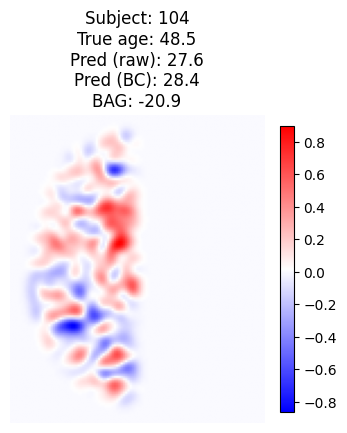

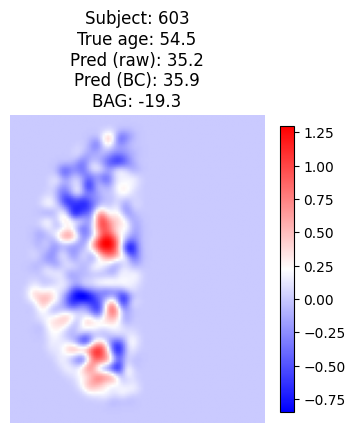

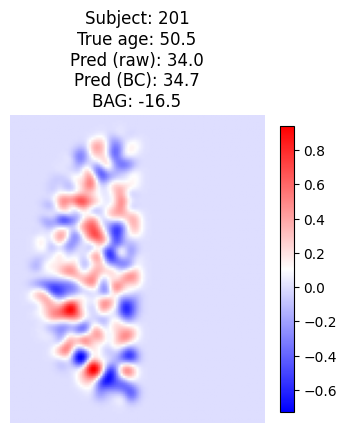

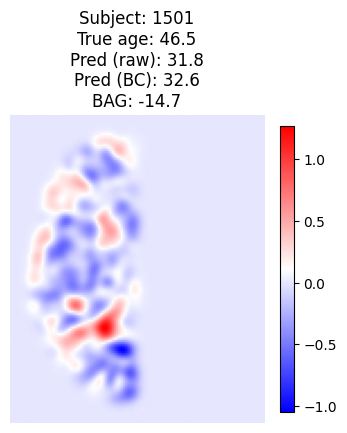

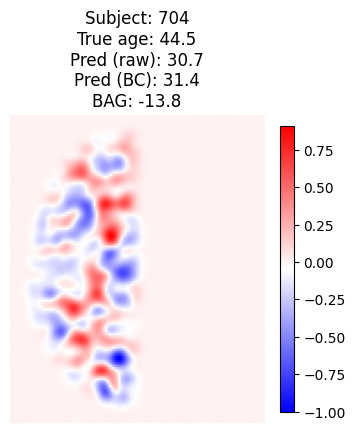

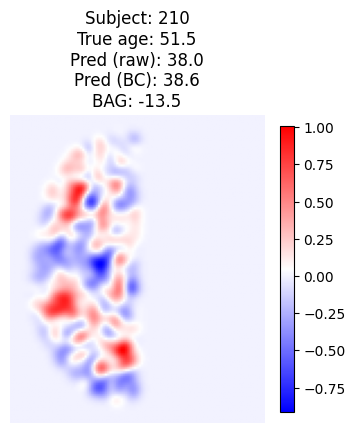

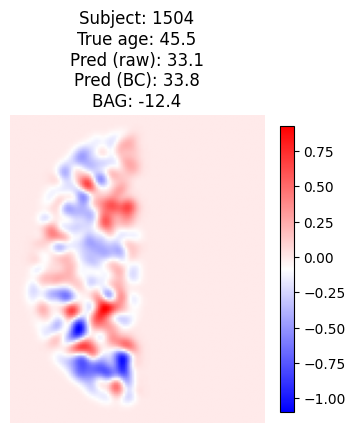

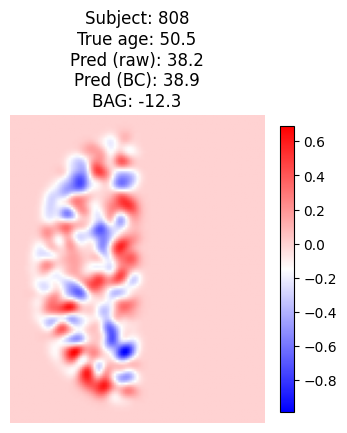

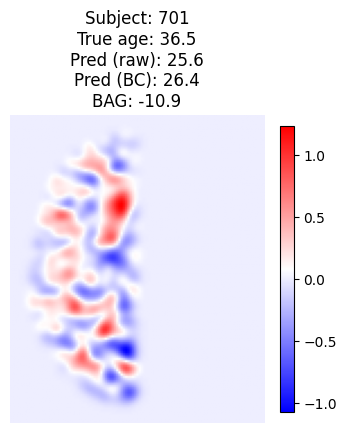

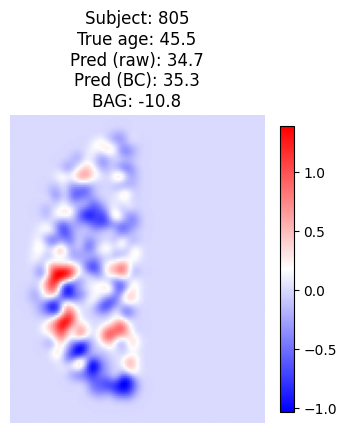

In [33]:
# Best cases sorted after bias-corrected predictions (smallest BAG)
for _, row in best_cases.iterrows():
    title = (
    f"Subject: {row['participant_id']}\n"
    f"True age: {row['age_m6']:.1f}\n"
    f"Pred (raw): {row['predicted_age']:.1f}\n"
    f"Pred (BC): {row['predicted_age_bc']:.1f}\n"
    f"BAG: {row['brain_age_gap']:.1f}")

    show_asymmetry_image(row["image_path"], title=title)

# red/positive values: rightward asymmetry
# blue/negative values: leftward asymmetry

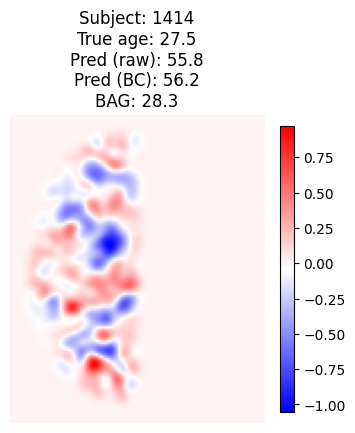

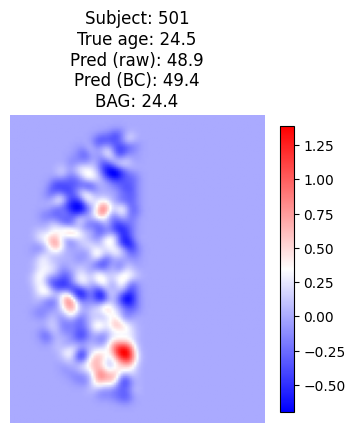

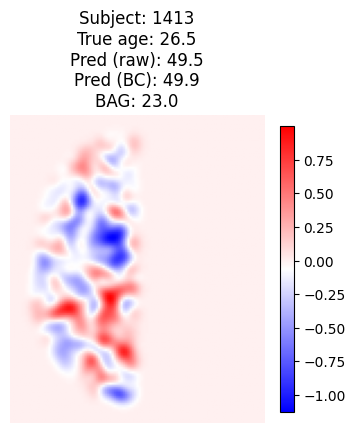

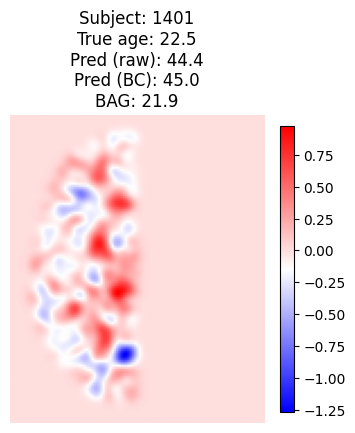

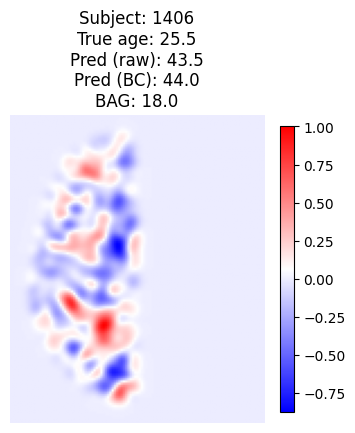

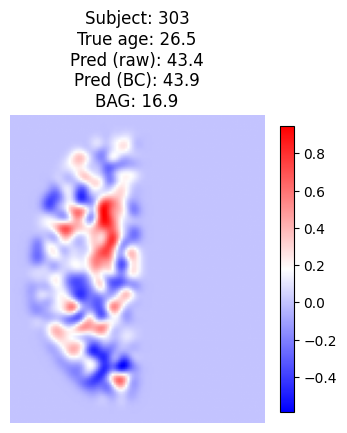

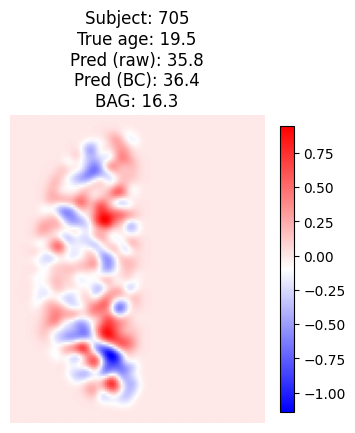

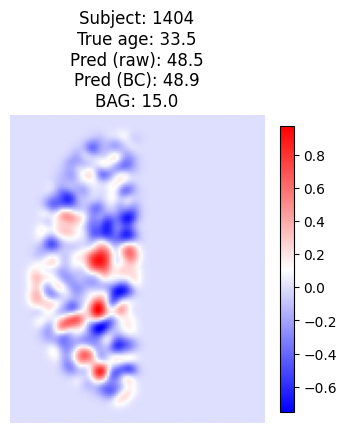

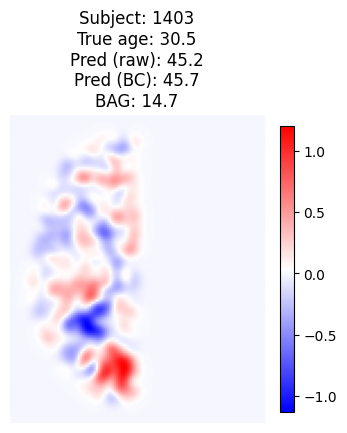

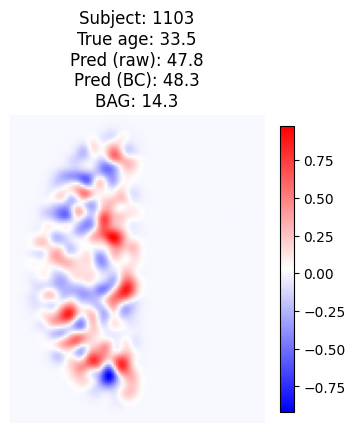

In [34]:
# Worst cases sorted after bias-corrected predictions (largest BAG)
for _, row in worst_cases.iterrows():
    title = (
    f"Subject: {row['participant_id']}\n"
    f"True age: {row['age_m6']:.1f}\n"
    f"Pred (raw): {row['predicted_age']:.1f}\n"
    f"Pred (BC): {row['predicted_age_bc']:.1f}\n"
    f"BAG: {row['brain_age_gap']:.1f}")

    show_asymmetry_image(row["image_path"], title=title)

Conclusions: Nothing suspicious.

## Save results

In [64]:
#df_ms.to_csv("smoothed_MS_brain_age_predictions_m6.csv", index=False)